# Лабораторная работа: Решение ОДУ

- Студент: Платов Дмитрий Константинович
- Группа: 6
- Дата: 21.05.26

### Цель работы
Изучение методов решения ОДУ.

<br><br>
### Ход работы

### 0. Импорт необходимых библиотек, задание констант

In [1]:
import numpy as np
import matplotlib.pyplot as plt

INTERVAL = (0, 10)
f = lambda x, y: y * np.cos(x)
f_exact = lambda x: np.exp(np.sin(x))
IC = 1

### 1. Реализация одношаговых методов (метода Рунге-Кутта 4-го порядка)

In [2]:
def runge_kutta_method(f: callable, IC: int, interval: tuple, cnt_points: int):
    x = np.linspace(interval[0], interval[1], cnt_points)
    y = np.zeros(cnt_points)
    h = (interval[1] - interval[0]) / (cnt_points - 1)
    y[0] = IC

    for i in range(0, cnt_points - 1):
        k_0 = f(x[i], y[i])
        k_1 = f(x[i] + h / 2, y[i] + h / 2 * k_0)
        k_2 = f(x[i] + h / 2, y[i] + h / 2 * k_1)
        k_3 = f(x[i] + h, y[i] + h * k_2)
        y[i + 1] = y[i] + h / 6 * (k_0 + 2 * k_1 + 2 * k_2 + k_3)

    return x, y

### 2. Реализация многошаговых методов (метода Адамса) 

In [3]:
def adams_method(f: callable, IC: int, interval: tuple, cnt_points: int):
    x = np.linspace(interval[0], interval[1], cnt_points)
    y = np.zeros(cnt_points)
    h = (interval[1] - interval[0]) / (cnt_points - 1)
    y[0] = IC

    initial_x, initial_y = runge_kutta_method(f, IC, (x[0], x[3]), 4)
    y[:4] = initial_y

    for i in range(3, cnt_points - 1):
        y[i + 1] = h / 24 * (
                55 * f(x[i], y[i]) - 59 * f(x[i - 1], y[i - 1]) + 37 * f(x[i - 2], y[i - 2]) - 9 * f(x[i - 3],
                                                                                                     y[i - 3])) + y[i]
    return x, y

### 3. Сравнение с точным решением

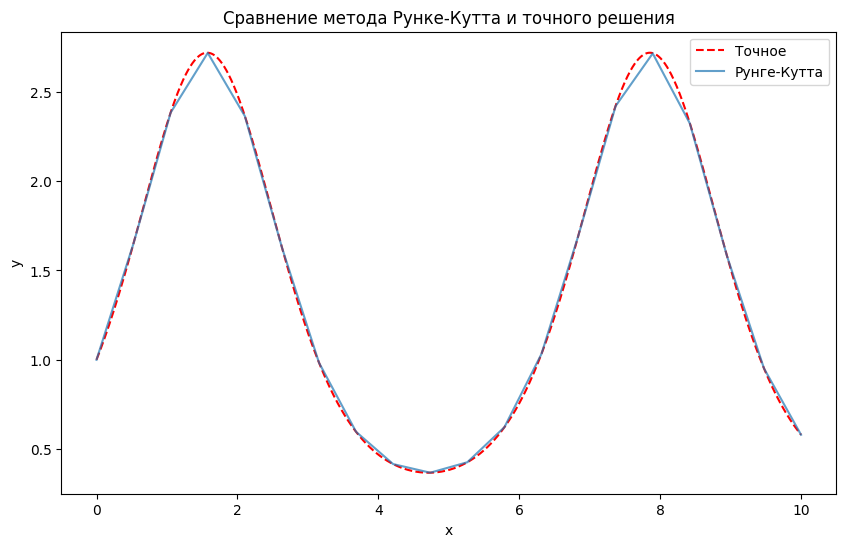

In [4]:
x_exact = np.linspace(INTERVAL[0], INTERVAL[1], 1000)
y_exact = f_exact(x_exact)
x_runge, y_runge = runge_kutta_method(f, IC, INTERVAL, 20)
x_adams, y_adams = adams_method(f, IC, INTERVAL, 20)

plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, ls='--', color='red', label='Точное')
plt.plot(x_runge, y_runge, alpha=0.7, label='Рунге-Кутта')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение метода Рунке-Кутта и точного решения')
plt.legend()
plt.show()

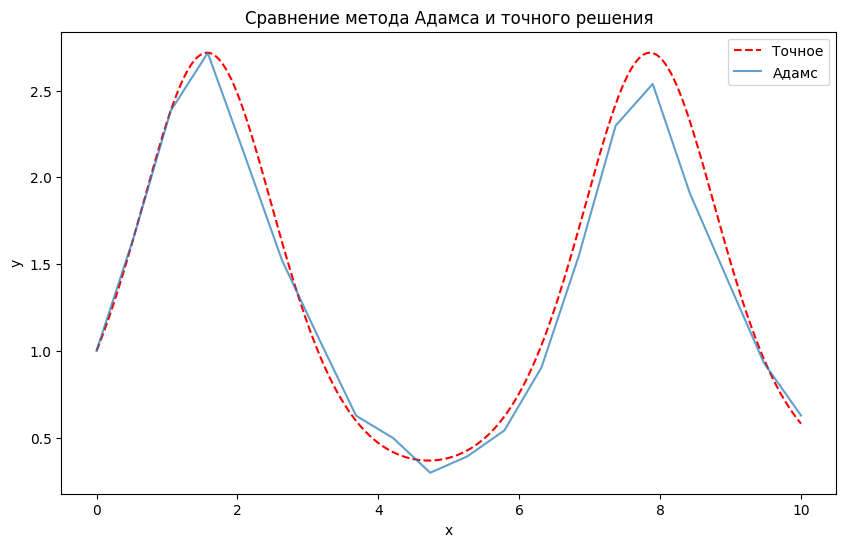

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, ls='--', color='red', label='Точное')
plt.plot(x_adams, y_adams, alpha=0.7, label='Адамс')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение метода Адамса и точного решения')
plt.legend()
plt.show()

### 4. Графики абсолютной и относительной погрешности в зависимости от числа точек

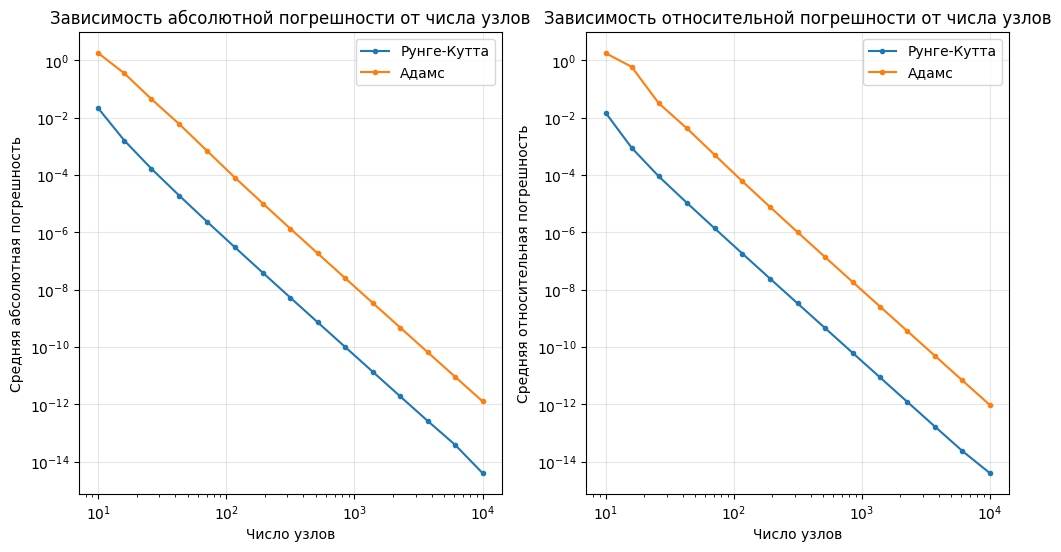

In [6]:
nodes_counts = np.logspace(1, 4, 15, dtype=int)
runge_errors_abs = []
runge_errors_rel = []
adams_errors_abs = []
adams_errors_rel = []

for n in nodes_counts:
    x_runge, y_runge = runge_kutta_method(f, IC, INTERVAL, n)
    x_adams, y_adams = adams_method(f, IC, INTERVAL, n)
    y_exact = f_exact(x_runge)

    runge_errors_abs.append(np.abs(y_exact - y_runge).mean())
    runge_errors_rel.append(np.abs((y_exact - y_runge) / y_exact).mean())

    adams_errors_abs.append(np.abs(y_exact - y_adams).mean())
    adams_errors_rel.append(np.abs((y_exact - y_adams) / y_exact).mean())

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.loglog(nodes_counts, runge_errors_abs, '-o', markersize=3, label='Рунге-Кутта')
plt.loglog(nodes_counts, adams_errors_abs, '-o', markersize=3, label='Адамс')
plt.xlabel('Число узлов')
plt.ylabel('Средняя абсолютная погрешность')
plt.title('Зависимость абсолютной погрешности от числа узлов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.loglog(nodes_counts, runge_errors_rel, '-o', markersize=3, label='Рунге-Кутта')
plt.loglog(nodes_counts, adams_errors_rel, '-o', markersize=3, label='Адамс')
plt.xlabel('Число узлов')
plt.ylabel('Средняя относительная погрешность')
plt.title('Зависимость относительной погрешности от числа узлов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Выводы

- Метод Рунге-Кутта точнее метода Адамса при одинаковом количестве узлов, но проигрывает ему в вычислительной эффективности из-за большего числа расчётов правой части на шаге.
- Метод Адамса является разумным компромиссом - незначительная потеря точности компенсируется существенной экономией вычислений после стартовых четырёх точек.
- Выбор метода зависит от приоритета задачи - если важна максимальная точность, лучше использовать Рунге-Кутта, если критично время счёта, предпочтительнее Адамс.